# Bước 1: Nhập Các Thư Viện Và Dữ Liệu Cần Thiết

 ### Nhập các thư viện cần thiết

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### Nhập bộ dữ liệu Amazon CE Sale Products

In [4]:
df = pd.read_csv('/content/electronics.csv', sep=None, engine='python')

### Kiểm tra dữ liệu

In [5]:
df.head(10)

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,3.0,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0
5,0,5,2.0,1999-07-12,Female,Portable Audio & Video,NaN,1999,NaN,0
6,0,6,5.0,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
7,0,7,2.0,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
8,0,8,4.0,1999-07-16,Female,Portable Audio & Video,NaN,1999,NaN,0
9,0,9,5.0,1999-08-20,Female,Portable Audio & Video,NaN,1999,NaN,0


# **Giai đoạn 1: Gợi ý dựa trên nội dung**

Chúng ta quan tâm đến cột category, brand, year

In [6]:
product = df[['category','brand','year']]

Kiểm tra 10 dòng đầu tiên của bộ dữ liệu mới

In [7]:
product.head(10)

,category,brand,year
0,Portable Audio & Video,NaN,1999
1,Portable Audio & Video,NaN,1999
2,Portable Audio & Video,NaN,1999
3,Portable Audio & Video,NaN,1999
4,Portable Audio & Video,NaN,1999
5,Portable Audio & Video,NaN,1999
6,Portable Audio & Video,NaN,1999
7,Portable Audio & Video,NaN,1999
8,Portable Audio & Video,NaN,1999
9,Portable Audio & Video,NaN,1999


## Bước 2: Thực Hiện EDA Đối Với Bộ Dữ Liệu

### Khám phá chung cho bộ dữ liệu

In [8]:
product.dtypes

,0
category,object
brand,object
year,int64


In [11]:
# Xác định số dòng và cột
product.shape

(1292954, 3)

In [12]:
# Xác định số dòng bị thiếu của dữ liệu
product.isnull().sum()

,0
category,0
brand,961834
year,0


# Bước 3: Xử lý dữ liệu

### Xử lý dữ liệu null

In [13]:
#xử lý dữ liệu null và chuẩn hóa
product_category = product['category'].fillna('')
product_brand = product['brand'].fillna('')
product_year = product['year'].fillna(0).astype(str) #Chuyển đổi năm thành chuỗi


In [14]:
# Kết hợp các cột thành một chuỗi duy nhất
product_features = product_category + ' ' + product_brand + ' ' + product_year

In [15]:
# Tạo một DataFrame ánh xạ item_id và index để dễ tra cứu
item_to_index = pd.Series(product.index, index=df['item_id']).drop_duplicates()

## Xử lý dữ liệu mô tả bằng phương pháp TF-IDF

In [16]:
tfidf = TfidfVectorizer(stop_words='english')

# Chuyển đổi dữ liệu features thành ma trận TF-IDF
product_matrix = tfidf.fit_transform(product_features)

In [17]:
product_matrix.shape

(1292954, 90)

## Bước 4: Tiến Hành Đề Xuất Dựa Trên Một Sản Phẩm Mẫu

In [18]:
ex_item_id = 1
# Lấy index của sản phẩm trong DataFrame
ex_index = item_to_index[ex_item_id].iloc[0]
# Lấy features của sản phẩm mẫu
product_test_features = product_features[ex_index]
# Tìm giá trị TF-IDF của sản phẩm mẫu bằng tfidf.transform
product_test_matrix = tfidf.transform([product_test_features])

In [19]:
product_test_matrix.shape

(1, 90)

In [27]:
# Ứng dụng cosine_similarity
sim_scores = cosine_similarity(product_test_matrix, product_matrix).tolist()[0]
# Tiến hành sắp xếp cosine_similarity từ cao nhất đến thấp nhất
sim_scores = sorted(enumerate(sim_scores), key=lambda i: i[1], reverse=True)
# Lấy 10 sản phẩm có cosine_similarity cao nhất
sim_scores = sim_scores[1:11]

In [ ]:
#In ra tên của các sản phẩm được đề xuất
product_indices = [i[0] for i in sim_scores]
print(product.iloc[product_indices])

                    category brand  year
42   Computers & Accessories    HP  2000
75   Computers & Accessories    HP  2000
76   Computers & Accessories    HP  2000
77   Computers & Accessories    HP  2000
96   Computers & Accessories    HP  2000
104  Computers & Accessories    HP  2000
113  Computers & Accessories    HP  2000
140  Computers & Accessories    HP  2000
160  Computers & Accessories    HP  2000
167  Computers & Accessories    HP  2000


# **Giai đoạn 2: Gợi ý dựa trên đánh giá của người dùng**
Collaborative filtering

In [28]:
ratings = df[['user_id', 'item_id', 'rating']]

In [22]:
ratings.head(10)

,user_id,item_id,rating
0,0,0,5.0
1,1,0,5.0
2,2,0,3.0
3,3,0,1.0
4,4,0,2.0
5,5,0,2.0
6,6,0,5.0
7,7,0,2.0
8,8,0,4.0
9,9,0,5.0


In [23]:
ratings.isnull().sum()

,0
user_id,0
item_id,0
rating,0


In [24]:
ratings = ratings.sample(50000, random_state=42)  # lấy ngẫu nhiên 50k dòng

In [26]:
# Tạo ma trận user-item
user_item_matrix = ratings.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating'
).fillna(0)
#Xem trước 10 dòng của ma trận mới tạo
user_item_matrix.head(10)

item_id,0,1,2,3,10,13,14,16,17,24,...,9520,9533,9537,9540,9541,9542,9543,9544,9551,9553
user_id,,,,,,,,,,,,,,,,,,,,,
23,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
338,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
345,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
385,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Tính cosine similarity giữa người dùng
item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

In [ ]:
# Lấy danh sách item_id gốc (từ cột của user_item_matrix)
item_ids = list(user_item_matrix.columns)

# Ví dụ: item gốc có id = 123
ex_item_id = 123

# Tìm vị trí của item đó trong item_ids
ex_index = item_ids.index(ex_item_id)

# Lấy similarity scores
sim_scores = item_similarity[ex_index]

# Sắp xếp từ cao xuống thấp
sim_scores = sorted(enumerate(sim_scores), key=lambda x: x[1], reverse=True)

# Bỏ chính nó đi
sim_scores = sim_scores[1:11]

# Lấy danh sách item gợi ý theo ID gốc
recommended_items = [item_ids[i[0]] for i in sim_scores]

In [ ]:
print("Item gốc:", ex_item_id)
print("Top 10 item tương tự:", recommended_items)

Item gốc: 123
Top 10 item tương tự: [0, 1, 2, 3, 10, 13, 14, 16, 17, 24]


# **Giai đoạn 3: Hybrid system**

In [ ]:
# Tạo bảng sản phẩm duy nhất
product = df[['item_id', 'category', 'brand', 'year']].drop_duplicates().reset_index(drop=True)

# --- Content-based filtering ---
# Ghép các thuộc tính để tạo feature text
product['features'] = (
    product['category'].fillna('') + " " +
    product['brand'].fillna('') + " " +
    product['year'].astype(str)
)

# TF-IDF
tfidf = TfidfVectorizer()
product_matrix = tfidf.fit_transform(product['features'])

In [ ]:
def get_content_recommendations(item_title, top_n=10):
    # Tìm kiếm chỉ mục của sản phẩm dựa trên tiêu đề
    item_indices = product[product['features'].str.contains(item_title, na=False)].index
    if item_indices.empty:
        print(f"Warning: Item with title '{item_title}' not found in features.")
        return pd.DataFrame(columns=['item_id','category','brand','year','cb_score'])

    # Lấy chỉ mục của sản phẩm đầu tiên tìm thấy
    item_index = item_indices[0]
    # Lấy mô tả của sản phẩm mẫu
    item_summary = product['features'][item_index]

    # Chuyển đổi sản phẩm mẫu thành ma trận TF-IDF
    item_matrix = tfidf.transform([item_summary])
    # Tính toán cosine similarity
    sim_scores = cosine_similarity(item_matrix, product_matrix).flatten()

    # Sắp xếp cosine similarity từ cao nhất đến thấp nhất
    sim_scores = sorted(enumerate(sim_scores), key=lambda i: i[1], reverse=True)
    # Bỏ chính nó (index 0) và lấy top_n
    sim_scores = sim_scores[1:top_n+1]

    # Lấy index và score
    product_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]

    # Lấy thông tin sản phẩm
    recommendations = product.iloc[product_indices][['item_id','category','brand','year']].reset_index(drop=True)
    recommendations['score'] = scores
    recommendations['source'] = 'CB' # CB = Content-Based

    return recommendations

# Chạy thử
import random
item_title = random.choice(product['features'].dropna().tolist())
print("Content-based recommendations for item:", item_title)
print(get_content_recommendations(item_title, top_n=10))


Content-based recommendations for item: Headphones Jabra 2014
   item_id    category  brand  year     score source
0     5142  Headphones  Jabra  2014  1.000000     CB
1     5146  Headphones  Jabra  2014  1.000000     CB
2     5485  Headphones  Jabra  2015  0.892683     CB
3     6015  Headphones  Jabra  2015  0.892683     CB
4     6699  Headphones  Jabra  2015  0.892683     CB
5     7482  Headphones  Jabra  2015  0.892683     CB
6     2900  Headphones  Jabra  2013  0.847579     CB
7     2921  Headphones  Jabra  2013  0.847579     CB
8     3338  Headphones  Jabra  2013  0.847579     CB
9     9106  Headphones  Jabra  2017  0.838498     CB


In [ ]:
def get_cf_recommendations(user_id, top_n=10):
    if user_id not in user_item_matrix.index:
        return pd.DataFrame(columns=['category','brand','score','source'])

    # Bước 1: Lấy ratings của user
    user_ratings = user_item_matrix.loc[user_id]
    # Bước 2: Tính điểm gợi ý dựa trên item tương tự
    scores = {}

    for item, rating in user_ratings[user_ratings > 0].items():
        similar_items = item_similarity_df[item].sort_values(ascending=False)
        for sim_item, sim_score in similar_items.items():
            if sim_item != item and sim_item not in user_ratings[user_ratings > 0]:
                scores[sim_item] = scores.get(sim_item, 0) + sim_score * rating

    # Bước 3: Chọn top N sản phẩm
    top_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    if not top_items: # Nếu không có gợi ý nào
        return pd.DataFrame(columns=['item_id', 'category', 'brand', 'score', 'source'])

    # Bước 4: Trả về DataFrame kết quả
    recs_df = pd.DataFrame(top_items, columns=['item_id', 'score'])
    product_info = product[['item_id', 'category', 'brand']].drop_duplicates()
    recs_df = pd.merge(recs_df, product_info, on='item_id', how='left')

    recs_df['source'] = 'CF' # CF = Collaborative Filtering

    return recs_df[['item_id', 'category', 'brand', 'score', 'source']] # Sắp xếp lại cột cho đồng nhất

# Chạy thử
import random
sample_user = random.choice(user_item_matrix.index.tolist())
cf_result = get_cf_recommendations(sample_user, top_n=10)
print(cf_result)


   item_id                 category       brand     score source
0     3136  Computers & Accessories  Sennheiser  0.099449     CF
1      283    Car Electronics & GPS      Garmin  0.042138     CF
2     6156  Security & Surveillance         NaN  0.000000     CF
3     6155   Portable Audio & Video         NaN  0.000000     CF
4     6154  Computers & Accessories         NaN  0.000000     CF
5     6152    Car Electronics & GPS         NaN  0.000000     CF
6     6150   Portable Audio & Video         NaN  0.000000     CF
7     6149  Computers & Accessories         NaN  0.000000     CF
8     6148  Computers & Accessories         NaN  0.000000     CF
9     6147           Camera & Photo         NaN  0.000000     CF


### 👉 Ý tưởng: một sản phẩm càng giống với sản phẩm user đã đánh giá cao, thì điểm nó càng cao.

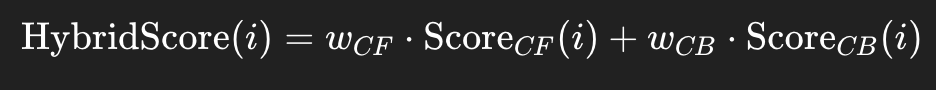

In [ ]:
def hybrid_recommender(user_id, item_title, weight_cf=0.5, weight_cb=0.5, top_n=10):
    # Lấy đề xuất từ CF
    cf_recs_df = get_cf_recommendations(user_id, top_n=top_n*2)

    if not cf_recs_df.empty:
        cf_recs = cf_recs_df[['category','brand','score','source']].copy()
    else:
        cf_recs = pd.DataFrame(columns=['category','brand','score','source'])


    # Lấy đề xuất từ Content-Based (CB)
    cb_recs = get_content_recommendations(item_title, top_n=top_n*2)

    # Gộp 2 bảng (cùng key category+brand)
    all_recs = pd.concat([cf_recs, cb_recs],ignore_index=True )
    all_recs = all_recs.dropna(subset=['category'])  # bỏ các dòng toàn NaN

    # Gom nhóm và tính điểm hybrid
    hybrid_scores = (
        all_recs.groupby(['category','brand','source'])['score'].mean().reset_index()
    )

    # Map trọng số theo nguồn
    hybrid_scores['weighted_score'] = hybrid_scores.apply(
        lambda row: row['score']*weight_cf if row['source']=='CF' else row['score']*weight_cb,
        axis=1
    )

    # Lấy max điểm mỗi (category, brand)
    final_scores = (
        hybrid_scores.groupby(['category','brand'])['weighted_score']
        .sum()
        .reset_index()
        .sort_values('weighted_score', ascending=False)
        .head(top_n)
    )

    return final_scores


In [ ]:
user_id = random.choice(user_item_matrix.index.tolist())  # Lấy ngẫu nhiên một user
item_title = random.choice(product['features'].tolist())  # Lấy ngẫu nhiên một sản phẩm
print("Hybrid recommendations for user:", user_id, "and item:", item_title)
print(hybrid_recommender(user_id, item_title, weight_cf=0.5, weight_cb=0.5, top_n=10))

Hybrid recommendations for user: 473473 and item: Portable Audio & Video  2009
                  category     brand  weighted_score
5   Portable Audio & Video      Sony        0.411113
4   Portable Audio & Video   Philips        0.391676
1           Camera & Photo    Funlux        0.000000
0           Camera & Photo  Fujifilm        0.000000
3               Headphones      Sony        0.000000
2  Computers & Accessories  XShields        0.000000
